# Rice Leaf Disease Classification — Notebook
## This notebook is the *evidence layer* for the project:
## - Dataset integrity checks + split sanity
## - Model training (optional) and evaluation
## - Statistical validation (McNemar’s test)
## - Confidence-based rejection analysis
## - Inference export (image-level metadata)
## - Explainability (Grad-CAM)
#
## It is designed to generate tables/figures useful for the final report.

## Kaggle-specific dataset resolution (Rice_leaf_Diease only) + 10→8 class merge + re-splitting
## This section enforces:
## 1) Use only "Rice_leaf_Diease" (ignore rice_Leaf_AUG)
## 2) Merge Kaggle's train+test into a single pool
## 3) Map original 10 class folder names → 9 unified classes
## 4) Create new stratified train/valid/test splits with seed=42
## 5) Verify constraints before any training/eval happens

In [36]:
import os
import json
import random
from dataclasses import dataclass

from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from sklearn.model_selection import train_test_split

# Statistical test
from statsmodels.stats.contingency_tables import mcnemar

# For Grad-CAM
import cv2

# %%
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

@dataclass
class CFG:
    # ---- Paths (EDIT THESE) ----
    PROJECT_ROOT: str = "/Users/mustaphanasser/Desktop/datawarehouse"  # <- edit
    DATA_ROOT: str = "/Users/mustaphanasser/Desktop/datawarehouse/rice_disease_detection"  # <- edit
    
    # Expected folder structure:
    # DATA_ROOT/
    #   train/<class folders>  (optional)
    #   valid/<class folders>  (optional)
    #   test/<class folders>   (optional)
    #
    # Or a single raw folder:
    # DATA_ROOT/raw/<class folders>
    
    # Models + outputs
    OUT_DIR: str = "artifacts/notebook_outputs"
    CNN_MODEL_PATH: str = "artifacts/models/custom_cnn.keras"          # saved model
    EFF_MODEL_PATH: str = "artifacts/models/efficientnetv2b0.keras"    # saved model


    # ---- Data / Training ----
    IMG_SIZE: Tuple[int, int] = (224, 224)
    BATCH_SIZE: int = 8
    EPOCHS: int = 20
    LR: float = 1e-4
    
    # Confidence rejection threshold (your choice)
    REJECT_THRESHOLD: float = 0.60
    
    # Train toggle (if False, notebook will load models from disk)
    DO_TRAIN: bool = False
    
cfg = CFG()

OUT_DIR = Path(cfg.PROJECT_ROOT) / cfg.OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /Users/mustaphanasser/Desktop/datawarehouse/artifacts/notebook_outputs


In [8]:
from pathlib import Path
import re
import shutil

SEED = 42
rng = np.random.default_rng(SEED)

def _canon(s: str) -> str:
    """Canonicalize folder names to avoid space/case/underscore chaos."""
    s = s.strip().lower()
    s = re.sub(r"[\s\-]+", "_", s)      # spaces/hyphens -> underscore
    s = re.sub(r"[^a-z0-9_]", "", s)    # drop weird chars
    return s

def resolve_kaggle_rice_leaf_diease(kaggle_root: str) -> Path:
    """
    kaggle_root is the folder containing both:
      - rice_Leaf_AUG/
      - Rice_leaf_Diease/
    We force selecting Rice_leaf_Diease.
    """
    root = Path(kaggle_root)
    if not root.exists():
        raise FileNotFoundError(f"Kaggle root not found: {root}")

    candidates = [p for p in root.iterdir() if p.is_dir()]
    names = {p.name: p for p in candidates}

    if "Rice_Leaf_Disease" not in names:
        raise FileNotFoundError(
            f'Expected folder "Rice_Leaf_Diease" inside {root}. Found: {[p.name for p in candidates]}'
        )
    chosen = names["Rice_Leaf_Disease"]

    # must contain train/ and test/
    train_dir = chosen / "train"
    test_dir  = chosen / "test"
    if not train_dir.exists() or not test_dir.exists():
        raise FileNotFoundError(f"{chosen} must contain train/ and test/ subfolders.")

    return chosen

def scan_kaggle_train_test(base: Path, img_exts=(".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff")) -> pd.DataFrame:
    rows = []
    for split in ["train", "test"]:
        split_dir = base / split
        for cls_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
            for p in cls_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in img_exts:
                    rows.append({
                        "path": str(p),
                        "orig_split": split,
                        "orig_label": cls_dir.name,
                        "orig_label_canon": _canon(cls_dir.name)
                    })
    return pd.DataFrame(rows)

# === USER EDIT (only this path usually changes) ===
KAGGLE_DOWNLOAD_ROOT = "/Users/mustaphanasser/Desktop/datawarehouse/rice_disease_detection"  # <- folder containing both rice_Leaf_AUG and Rice_leaf_Diease

base_dir = resolve_kaggle_rice_leaf_diease(KAGGLE_DOWNLOAD_ROOT)
print("Using dataset:", base_dir)

raw_df_10 = scan_kaggle_train_test(base_dir)
print("Total images scanned:", len(raw_df_10))
print("Original class folders found:", sorted(raw_df_10["orig_label"].unique()))

# --- Define your 10→8 merge map ---
# Key: canonicalized original folder name
# Value: canonicalized final 9-class label
#
# IMPORTANT:
# 1) Put EXACT mappings for ALL 10 original classes
# 2) If you merged multiple into one, point them to same value
#
# Update these values to match your actual merge decisions.

# --- Define your 10→9 merge map (two merge groups) ---
# Group A: narrow_brown_spot + brown_spot -> brown_spot
# Group B: sheath_blight + bacterial_sheath_blight -> sheath_blight (if bacterial_sheath_blight exists)

MERGE_MAP_10_TO_9 = {
    _canon("bacterial_leaf_blight"): _canon("bacterial_leaf_blight"),
    _canon("leaf_blast"):            _canon("leaf_blast"),
    _canon("neck_blast"):            _canon("neck_blast"),
    _canon("leaf_scald"):            _canon("leaf_scald"),
    _canon("tungro"):                _canon("tungro"),
    _canon("healthy"):               _canon("healthy"),
    _canon("rice hispa"):            _canon("rice_hispa"),

    # Group A merge
    _canon("brown_spot"):            _canon("brown_spot"),
    _canon("narrow_brown_spot"):     _canon("brown_spot"),

    # Group B merge
    _canon("sheath blight"):         _canon("sheath_blight"),
    # Add ONLY if present in the dataset; we'll handle presence below
    _canon("bacterial sheath blight"): _canon("sheath_blight"),
}


# Validate mapping covers all found classes
found = set(raw_df_10["orig_label_canon"].unique())

# Remove keys that aren't in this dataset (e.g., bacterial_sheath_blight might not exist)
merge_map_active = {k: v for k, v in MERGE_MAP_10_TO_9.items() if k in found}

missing = sorted(found - set(merge_map_active.keys()))
if missing:
    raise ValueError(f"Missing mappings for these original classes: {missing}")

raw_df_10["label_9"] = raw_df_10["orig_label_canon"].map(merge_map_active)
if raw_df_10["label_9"].isna().any():
    bad = raw_df_10[raw_df_10["label_9"].isna()]["orig_label"].unique()
    raise ValueError(f"Unmapped labels after mapping. Check names: {bad}")

final_classes = sorted(raw_df_10["label_9"].unique())
print("Final merged classes:", final_classes)
print("Number of final classes:", len(final_classes))

if len(final_classes) != 9:
    raise ValueError(
        f"Expected 9 final classes after merge, got {len(final_classes)}: {final_classes}\n"
        f"Tip: check whether 'bacterial sheath blight' exists or if another class name differs."
    )


# Merge Kaggle train+test into one pool, then stratified re-split
pool_df = raw_df_10[["path", "label_9"]].rename(columns={"label_9": "label"}).copy()

train_df, temp_df = train_test_split(
    pool_df, test_size=0.30, stratify=pool_df["label"], random_state=SEED
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.assign(split="train").reset_index(drop=True)
valid_df = valid_df.assign(split="valid").reset_index(drop=True)
test_df  = test_df.assign(split="test").reset_index(drop=True)

split_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

# Hard checks: stratification and no leakage by path
assert split_df["path"].is_unique, "Same image path appears in multiple splits (leakage)."

counts = split_df.groupby(["split", "label"]).size().unstack(fill_value=0)
display(counts)

# Save split index for reproducibility
out_split_csv = OUT_DIR / "split_index_8class_seed42.csv"
split_df.to_csv(out_split_csv, index=False)
print("Saved:", out_split_csv)

# Optional: materialize into folder structure train/valid/test with 8 subfolders (copies, not moves)
def materialize_split_folders(split_df: pd.DataFrame, out_root: Path, copy=True):
    out_root.mkdir(parents=True, exist_ok=True)
    for split in ["train","valid","test"]:
        (out_root / split).mkdir(parents=True, exist_ok=True)

    for _, row in split_df.iterrows():
        src = Path(row["path"])
        dst_dir = out_root / row["split"] / row["label"]
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / src.name
        if dst.exists():
            # if filename collision happens, make it unique
            stem, suf = src.stem, src.suffix
            dst = dst_dir / f"{stem}_{abs(hash(str(src)))%10**8}{suf}"
        if copy:
            shutil.copy2(src, dst)
        else:
            shutil.move(src, dst)

# Example usage:
MATERIALIZED_DIR = Path(cfg.PROJECT_ROOT) / "data" / "processed_8class"
materialize_split_folders(split_df, MATERIALIZED_DIR, copy=True)
print("Materialized to:", MATERIALIZED_DIR)


Using dataset: /Users/mustaphanasser/Desktop/datawarehouse/rice_disease_detection/Rice_Leaf_Disease
Total images scanned: 18445
Original class folders found: ['Neck_Blast', 'Rice Hispa', 'Sheath Blight', 'Tungro', 'bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot', 'neck_blast', 'rice_hispa', 'sheath_blight', 'tungro']
Final merged classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'neck_blast', 'rice_hispa', 'sheath_blight', 'tungro']
Number of final classes: 9


label,bacterial_leaf_blight,brown_spot,healthy,leaf_blast,leaf_scald,neck_blast,rice_hispa,sheath_blight,tungro
split,,,,,,,,,
test,264,548,283,325,309,198,253,280,307
train,1233,2561,1317,1514,1439,926,1180,1306,1435
valid,265,549,282,324,308,198,253,280,308


Saved: /Users/mustaphanasser/Desktop/datawarehouse/artifacts/notebook_outputs/split_index_8class_seed42.csv
Materialized to: /Users/mustaphanasser/Desktop/datawarehouse/data/processed_8class


## 1) Data sourcing + audit utilities

Normalized DATA_ROOT = /Users/mustaphanasser/Desktop/datawarehouse/data/processed_8class
Splits found: ['test', 'train', 'valid']
Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'neck_blast', 'rice_hispa', 'sheath_blight', 'tungro']
Total images: 18445
Saved: /Users/mustaphanasser/Desktop/datawarehouse/artifacts/notebook_outputs/class_counts_by_split.csv


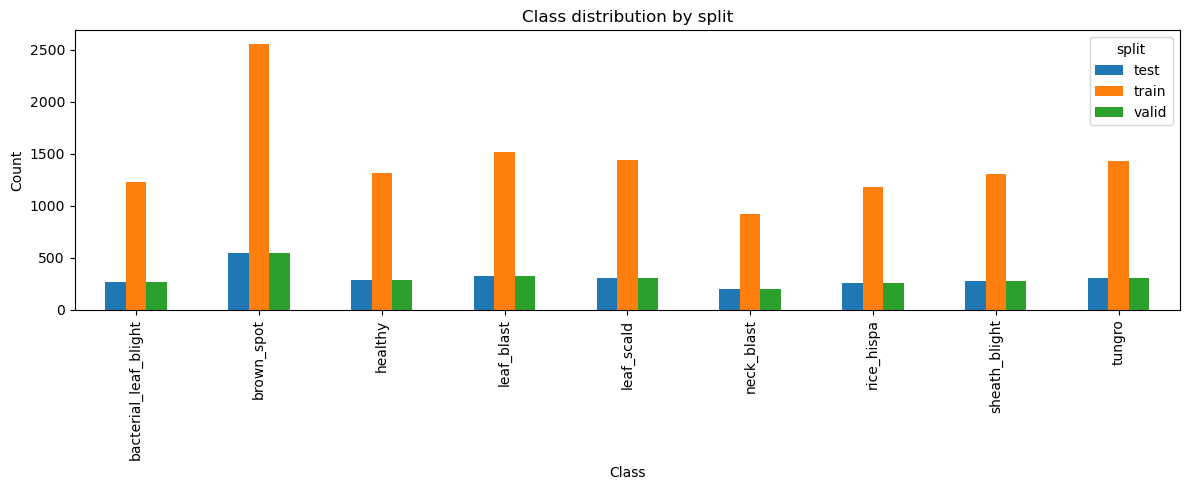

In [21]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")

def list_class_folders(root: str) -> List[str]:
    rootp = Path(root)
    if not rootp.exists():
        raise FileNotFoundError(f"DATA ROOT not found: {root}")
    return sorted([p.name for p in rootp.iterdir() if p.is_dir()])

def find_split_roots(data_root: str) -> Dict[str, Path]:
    """
    Detects whether dataset is already split into train/valid/test,
    or stored in raw/.
    """
    base = Path(data_root)
    candidates = {k: base / k for k in ["train", "valid", "val", "test", "raw"]}
    found = {k: p for k, p in candidates.items() if p.exists() and p.is_dir()}
    # Normalize 'val' -> 'valid' if used
    if "val" in found and "valid" not in found:
        found["valid"] = found["val"]
    return found

def scan_images(split_dir: Path) -> pd.DataFrame:
    """
    Returns dataframe with columns: path, split, label, filename
    """
    rows = []
    split_name = split_dir.name
    class_folders = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    for cls_dir in class_folders:
        cls = cls_dir.name
        for p in cls_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({
                    "path": str(p),
                    "split": split_name,
                    "label": cls,
                    "filename": p.name
                })
    return pd.DataFrame(rows)

# def normalize_data_root(data_root: str) -> str:
#     p = Path(data_root).expanduser().resolve()
#     if (p/"train").exists() or (p/"test").exists() or (p/"raw").exists():
#         return str(p)

#     # If exactly one subfolder, descend into it
#     kids = [d for d in p.iterdir() if d.is_dir()]
#     if len(kids) == 1:
#         return str(kids[0])

#     return str(p)

cfg.DATA_ROOT = str(MATERIALIZED_DIR)
print("Normalized DATA_ROOT =", cfg.DATA_ROOT)


split_roots = find_split_roots(cfg.DATA_ROOT)
split_roots

# Load dataset index
dfs = []
if "train" in split_roots and "test" in split_roots:
    dfs.append(scan_images(split_roots["train"]))
    if "valid" in split_roots:
        dfs.append(scan_images(split_roots["valid"]))
    dfs.append(scan_images(split_roots["test"]))
elif "raw" in split_roots:
    dfs.append(scan_images(split_roots["raw"]))
else:
    # If DATA_ROOT itself has class folders (no explicit split)
    # treat it as raw
    dfs.append(scan_images(Path(cfg.DATA_ROOT)))

data_df = pd.concat(dfs, ignore_index=True)
data_df.head(), data_df.shape

# Basic audit
print("Splits found:", sorted(data_df["split"].unique()))
print("Classes:", sorted(data_df["label"].unique()))
print("Total images:", len(data_df))

# Class counts by split
counts = data_df.groupby(["split", "label"]).size().reset_index(name="n")
pivot_counts = counts.pivot(index="label", columns="split", values="n").fillna(0).astype(int)
pivot_counts

# Save counts table for report use
pivot_counts.to_csv(OUT_DIR / "class_counts_by_split.csv")
pivot_counts.to_markdown(OUT_DIR / "class_counts_by_split.md")
print("Saved:", OUT_DIR / "class_counts_by_split.csv")

# Visual: class distribution by split
pivot_counts.plot(kind="bar", figsize=(12, 5))
plt.title("Class distribution by split")
plt.ylabel("Count")
plt.xlabel("Class")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution_by_split.png", dpi=200)
plt.show()

## 2) Dataset splitting (only if you currently have RAW)
If you already have train/valid/test and your pipeline manages it, skip this.
This section generates an *index split* (CSV) without moving files.

In [38]:
def make_stratified_split_index(raw_df: pd.DataFrame,
                                test_size=0.15,
                                valid_size=0.15,
                                seed=SEED) -> pd.DataFrame:
    """
    Create stratified train/valid/test assignment WITHOUT moving files.
    valid_size is fraction of total; implemented as split from remaining after test.
    """
    df = raw_df.copy()
    assert df["split"].nunique() == 1, "Expected RAW-only dataframe"
    
    train_valid, test = train_test_split(
        df, test_size=test_size, stratify=df["label"], random_state=seed
    )
    valid_frac_of_train_valid = valid_size / (1.0 - test_size)
    train, valid = train_test_split(
        train_valid, test_size=valid_frac_of_train_valid,
        stratify=train_valid["label"], random_state=seed
    )
    train = train.assign(split="train")
    valid = valid.assign(split="valid")
    test = test.assign(split="test")
    return pd.concat([train, valid, test], ignore_index=True)

if data_df["split"].nunique() == 1 and data_df["split"].iloc[0] in ["raw", Path(cfg.DATA_ROOT).name]:
    split_index_df = make_stratified_split_index(data_df, test_size=0.15, valid_size=0.15)
    split_index_df.to_csv(OUT_DIR / "split_index.csv", index=False)
    print("Saved split index:", OUT_DIR / "split_index.csv")
else:
    split_index_df = None
    print("Dataset already split (train/valid/test). Skipping split index generation.")

Dataset already split (train/valid/test). Skipping split index generation.



## 3) tf.data input pipeline


In [34]:

def build_label_maps(df: pd.DataFrame) -> Tuple[List[str], Dict[str, int], Dict[int, str]]:
    class_names = sorted(df["label"].unique())
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    idx_to_class = {i: c for c, i in class_to_idx.items()}
    return class_names, class_to_idx, idx_to_class

class_names, class_to_idx, idx_to_class = build_label_maps(data_df)
NUM_CLASSES = len(class_names)
class_names, NUM_CLASSES


def decode_img(path: tf.Tensor, img_size=(224,224)) -> tf.Tensor:
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_dataset_from_df(df: pd.DataFrame,
                         class_to_idx: Dict[str, int],
                         batch_size: int,
                         img_size: Tuple[int,int],
                         shuffle: bool = False) -> tf.data.Dataset:
    paths = df["path"].values.astype(str)
    labels = df["label"].map(class_to_idx).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 5000), seed=SEED, reshuffle_each_iteration=True)

    def _load(path, y):
        x = decode_img(path, img_size)
        return x, tf.one_hot(y, depth=NUM_CLASSES)

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def get_split_df(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    # normalize: your folders might use 'val' or 'valid'
    split_name = "valid" if split_name in ["val", "valid"] else split_name
    # accept folder name "train"/"test"/"valid"
    if split_name == "valid":
        # in case folder is actually named "val"
        return df[df["split"].isin(["valid", "val"])].reset_index(drop=True)
    return df[df["split"] == split_name].reset_index(drop=True)
    
print("data_df shape:", data_df.shape)
print("data_df splits:", sorted(data_df["split"].unique()))
print("data_df labels:", len(data_df["label"].unique()), sorted(data_df["label"].unique())[:20])
print("Example paths:", data_df["path"].head(3).tolist())


train_df = get_split_df(data_df, "train") if "train" in data_df["split"].unique() else None
valid_df = get_split_df(data_df, "valid") if any(s in data_df["split"].unique() for s in ["valid","val"]) else None
test_df  = get_split_df(data_df, "test")  if "test"  in data_df["split"].unique() else None

print("train_df:", None if train_df is None else train_df.shape)
print("valid_df:", None if valid_df is None else valid_df.shape)
print("test_df :", None if test_df  is None else test_df.shape)

print("splits present in data_df:", sorted(data_df["split"].unique()))

valid_name = "valid" if "valid" in data_df["split"].unique() else ("val" if "val" in data_df["split"].unique() else None)
valid_df = get_split_df(data_df, valid_name) if valid_name else None
print("valid_name used:", valid_name)


# If no explicit splits, but split_index_df exists, use it:
if train_df is None and split_index_df is not None:
    train_df = split_index_df[split_index_df["split"]=="train"].reset_index(drop=True)
    valid_df = split_index_df[split_index_df["split"]=="valid"].reset_index(drop=True)
    test_df  = split_index_df[split_index_df["split"]=="test"].reset_index(drop=True)

print("Train classes:", len(train_df["label"].unique()), sorted(train_df["label"].unique()))
print("Valid classes:", len(valid_df["label"].unique()), sorted(valid_df["label"].unique()))
print("Test classes :", len(test_df["label"].unique()),  sorted(test_df["label"].unique()))

missing_in_train = set(sorted(data_df["label"].unique())) - set(train_df["label"].unique())
print("Missing in train:", sorted(missing_in_train))


assert train_df is not None and valid_df is not None and test_df is not None, "Need train/valid/test split to proceed."
# ensure exact 9 classes present in every split (or at least train)
assert len(train_df["label"].unique()) == 9, "Train split does not contain all 8 classes."
assert set(valid_df["label"].unique()).issubset(set(train_df["label"].unique()))
assert set(test_df["label"].unique()).issubset(set(train_df["label"].unique()))


class_names = sorted(train_df["label"].unique())
NUM_CLASSES = len(class_names)
print("NUM_CLASSES:", NUM_CLASSES, class_names)

class_to_idx = {c:i for i,c in enumerate(class_names)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
NUM_CLASSES = len(class_names)

train_ds = make_dataset_from_df(train_df, class_to_idx, cfg.BATCH_SIZE, cfg.IMG_SIZE, shuffle=True)
valid_ds = make_dataset_from_df(valid_df, class_to_idx, cfg.BATCH_SIZE, cfg.IMG_SIZE, shuffle=False)
test_ds  = make_dataset_from_df(test_df,  class_to_idx, cfg.BATCH_SIZE, cfg.IMG_SIZE, shuffle=False)

xb, yb = next(iter(train_ds))
print("x batch:", xb.shape, xb.dtype, float(tf.reduce_min(xb)), float(tf.reduce_max(xb)))
print("y batch:", yb.shape, yb.dtype)
print("y sample (first 5):", yb[:5].numpy())

print("Unique train paths:", train_df["path"].nunique(), "rows:", len(train_df))
print("Overlap train-valid:", len(set(train_df["path"]) & set(valid_df["path"])))
print("Overlap train-test :", len(set(train_df["path"]) & set(test_df["path"])))
print("Overlap valid-test :", len(set(valid_df["path"]) & set(test_df["path"])))



len(train_df), len(valid_df), len(test_df)

data_df shape: (18445, 4)
data_df splits: ['test', 'train', 'valid']
data_df labels: 9 ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'neck_blast', 'rice_hispa', 'sheath_blight', 'tungro']
Example paths: ['/Users/mustaphanasser/Desktop/datawarehouse/data/processed_8class/train/bacterial_leaf_blight/bacterial_leaf_blight755.jpg', '/Users/mustaphanasser/Desktop/datawarehouse/data/processed_8class/train/bacterial_leaf_blight/bacterial_leaf_blight999.jpg', '/Users/mustaphanasser/Desktop/datawarehouse/data/processed_8class/train/bacterial_leaf_blight/bacterial_leaf_blight1043.jpg']
train_df: (12911, 4)
valid_df: (2767, 4)
test_df : (2767, 4)
splits present in data_df: ['test', 'train', 'valid']
valid_name used: valid
Train classes: 9 ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'neck_blast', 'rice_hispa', 'sheath_blight', 'tungro']
Valid classes: 9 ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald',

(12911, 2767, 2767)

## 4) Model builders: Custom CNN + EfficientNetV2B0
 Training is optional. If DO_TRAIN is False, models will be loaded from disk.

In [29]:
def build_custom_cnn(num_classes: int, img_size=(224,224)) -> keras.Model:
    inputs = keras.Input(shape=(*img_size, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="custom_cnn")

def build_efficientnetv2b0(num_classes: int, img_size=(224,224), train_base=False) -> keras.Model:
    inputs = keras.Input(shape=(*img_size, 3))
    
    # EfficientNetV2 preprocessing expects pixel values in [0,255] then preprocess_input,
    # but we already scaled to [0,1]. We'll convert back for correctness.
    x = layers.Lambda(lambda z: z * 255.0)(inputs)
    x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False, weights="imagenet", input_tensor=x
    )
    base.trainable = train_base

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="efficientnetv2b0")
    return model

def compile_model(model: keras.Model, lr: float):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

# %%
cnn = build_custom_cnn(NUM_CLASSES, cfg.IMG_SIZE)
eff = build_efficientnetv2b0(NUM_CLASSES, cfg.IMG_SIZE, train_base=False)

compile_model(cnn, cfg.LR)
compile_model(eff, cfg.LR)

cnn.summary()
eff.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,729 (1.49 MB)

 Trainable params: 390,729 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Model: "efficientnetv2b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ lambda[0][0]      │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c

 Total params: 5,930,841 (22.62 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)


## 5) Training (optional)
If you already trained models in scripts, set DO_TRAIN=False and load them below.

In [48]:
dcnn_path = Path(cfg.PROJECT_ROOT) / cfg.CNN_MODEL_PATH
eff_path = Path(cfg.PROJECT_ROOT) / cfg.EFF_MODEL_PATH
cnn_path.parent.mkdir(parents=True, exist_ok=True)
eff_path.parent.mkdir(parents=True, exist_ok=True)

history = {}

def train_cnn():
    print("Training Custom CNN (fresh run)...")
    return train_model(cnn, train_ds, valid_ds, cnn_path, epochs=cfg.EPOCHS)

def train_effnet():
    print("Training EfficientNetV2B0 (frozen base)...")
    hist_frozen = train_model(
        eff,
        train_ds,
        valid_ds,
        eff_path,
        epochs=max(5, cfg.EPOCHS // 2),
    )

    print("Unfreezing EfficientNet base for fine-tuning...")
    for layer in eff.layers:
        if isinstance(layer, tf.keras.Model):
            layer.trainable = True

    compile_model(eff, cfg.LR * 0.1)

    hist_unfrozen = train_model(
        eff,
        train_ds,
        valid_ds,
        eff_path,
        epochs=max(5, cfg.EPOCHS // 2),
    )

    return {"frozen": hist_frozen, "unfrozen": hist_unfrozen}

# ==========================================================
# FIX 2: Explicit, deterministic training policy
# ==========================================================

if cfg.DO_TRAIN:
    cnn_path.unlink(missing_ok=True)
    eff_path.unlink(missing_ok=True)


else:
    print("[mode] DO_TRAIN=False → load if possible, else train")

    if cnn_path.exists():
        print("Loading existing CNN:", cnn_path)
        cnn = keras.models.load_model(cnn_path)
    else:
        history["cnn"] = train_cnn()

    if eff_path.exists():
        print("Loading existing EfficientNet:", eff_path)
        eff = keras.models.load_model(eff_path)
    else:
        history["eff"] = train_effnet()



[mode] DO_TRAIN=False → load if possible, else train
Training Custom CNN (fresh run)...
Epoch 1/20


2026-01-16 23:03:35.090455: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1614/1614 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7794 - loss: 0.6136

2026-01-16 23:04:43.513043: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1614/1614 ━━━━━━━━━━━━━━━━━━━━ 77s 47ms/step - accuracy: 0.7913 - loss: 0.5973 - val_accuracy: 0.7907 - val_loss: 0.6167 - learning_rate: 1.0000e-04
Epoch 2/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 75s 46ms/step - accuracy: 0.7994 - loss: 0.5790 - val_accuracy: 0.7788 - val_loss: 0.6477 - learning_rate: 1.0000e-04
Epoch 3/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 75s 46ms/step - accuracy: 0.8047 - loss: 0.5666 - val_accuracy: 0.7853 - val_loss: 0.6057 - learning_rate: 1.0000e-04
Epoch 4/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 75s 46ms/step - accuracy: 0.8137 - loss: 0.5282 - val_accuracy: 0.7965 - val_loss: 0.5988 - learning_rate: 1.0000e-04
Epoch 5/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 75s 46ms/step - accuracy: 0.8195 - loss: 0.5223 - val_accuracy: 0.8027 - val_loss: 0.5867 - learning_rate: 1.0000e-04
Epoch 6/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.8278 - loss: 0.5032 - val_accuracy: 0.7857 - val_loss: 0.6085 - learning_rate: 1.0000e-04
Epoch 7/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/

ValueError: Requested the deserialization of a `Lambda` layer whose `function` is a Python lambda. This carries a potential risk of arbitrary code execution and thus it is disallowed by default. If you trust the source of the artifact, you can override this error by passing `safe_mode=False` to the loading function, or calling `keras.config.enable_unsafe_deserialization().

## 6) Evaluation utilities (metrics + confusion matrix + report exports)

2026-01-16 23:36:56.230500: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.
2026-01-16 23:37:07.906770: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


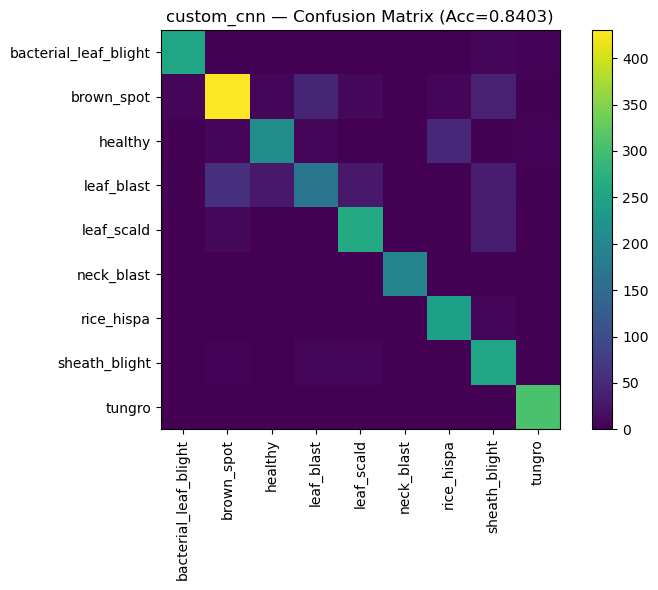

2026-01-16 23:37:29.576237: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


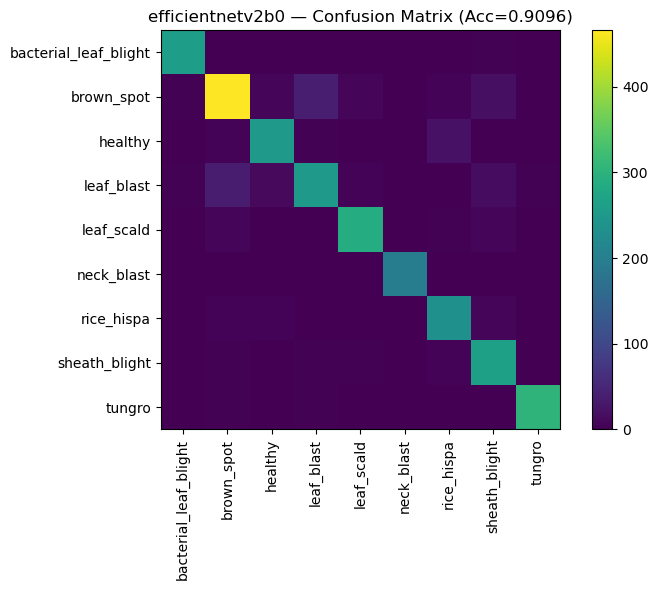

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Support
0,custom_cnn,0.840260,0.849513,0.857184,0.848028,0.842996,0.840260,0.836475,2767.0
1,efficientnetv2b0,0.909649,0.915637,0.920863,0.917491,0.910381,0.909649,0.909272,2767.0


In [50]:
def predict_dataset(model: keras.Model, ds: tf.data.Dataset) -> Tuple[np.ndarray, np.ndarray]:
    probs = model.predict(ds, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = np.concatenate([y.numpy().argmax(axis=1) for _, y in ds], axis=0)
    return y_true, y_pred

def evaluate_and_export(model: keras.Model, ds: tf.data.Dataset, name: str):
    y_true, y_pred = predict_dataset(model, ds)
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    # Save report and confusion matrix
    pd.DataFrame(report).transpose().to_csv(OUT_DIR / f"{name}_classification_report.csv")
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(OUT_DIR / f"{name}_confusion_matrix.csv")
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.title(f"{name} — Confusion Matrix (Acc={acc:.4f})")
    plt.xticks(range(len(class_names)), class_names, rotation=90)
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{name}_confusion_matrix.png", dpi=200)
    plt.show()

    return {
        "name": name,
        "accuracy": float(acc),
        "report_dict": report,
        "cm": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }


cnn_eval = evaluate_and_export(cnn, test_ds, "custom_cnn") if cnn_path.exists() else None
eff_eval = evaluate_and_export(eff, test_ds, "efficientnetv2b0") if eff_path.exists() else None


# Summary table (Accuracy + macro/weighted F1 etc.)
def extract_summary(eval_obj):
    r = eval_obj["report_dict"]
    return {
        "Model": eval_obj["name"],
        "Accuracy": eval_obj["accuracy"],
        "Macro Precision": r["macro avg"]["precision"],
        "Macro Recall": r["macro avg"]["recall"],
        "Macro F1": r["macro avg"]["f1-score"],
        "Weighted Precision": r["weighted avg"]["precision"],
        "Weighted Recall": r["weighted avg"]["recall"],
        "Weighted F1": r["weighted avg"]["f1-score"],
        "Support": r["accuracy"] if "accuracy" not in r else r["weighted avg"]["support"],
    }

summary_rows = []
if cnn_eval: summary_rows.append(extract_summary(cnn_eval))
if eff_eval: summary_rows.append(extract_summary(eff_eval))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / "model_summary_metrics.csv", index=False)
summary_df





In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# Collect ground truth and predictions
y_true = []
y_pred_cnn = []
y_pred_eff = []

for xb, yb in test_ds:
    y_true.append(np.argmax(yb.numpy(), axis=1))
    y_pred_cnn.append(np.argmax(cnn.predict(xb, verbose=0), axis=1))
    y_pred_eff.append(np.argmax(eff.predict(xb, verbose=0), axis=1))

y_true = np.concatenate(y_true)
y_pred_cnn = np.concatenate(y_pred_cnn)
y_pred_eff = np.concatenate(y_pred_eff)

# Classification reports
report_cnn = classification_report(
    y_true,
    y_pred_cnn,
    target_names=class_names,
    output_dict=True,
)

report_eff = classification_report(
    y_true,
    y_pred_eff,
    target_names=class_names,
    output_dict=True,
)

# Convert to DataFrame
cnn_df = pd.DataFrame(report_cnn).T
eff_df = pd.DataFrame(report_eff).T

# Keep only per-class rows
cnn_df = cnn_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]
eff_df = eff_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]

cnn_df["model"] = "custom_cnn"
eff_df["model"] = "efficientnetv2b0"

per_class_df = pd.concat([cnn_df, eff_df])
per_class_df.reset_index(names="class", inplace=True)

per_class_df

f1_pivot = per_class_df.pivot(index="class", columns="model", values="f1-score")
f1_pivot["f1_gap_eff_minus_cnn"] = (
    f1_pivot["efficientnetv2b0"] - f1_pivot["custom_cnn"]
)

f1_pivot.sort_values("f1_gap_eff_minus_cnn", ascending=False)

out_path = OUT_DIR / "per_class_f1_comparison_9class.csv"
f1_pivot.to_csv(out_path)
print("Saved:", out_path)



2026-01-16 23:50:26.568119: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Saved: /Users/mustaphanasser/Desktop/datawarehouse/artifacts/notebook_outputs/per_class_f1_comparison_9class.csv


2026-01-16 23:50:58.142028: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



## 7) Statistical validation — McNemar’s test
Uses paired predictions (same test images for both models).

In [52]:
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    # b = A correct, B wrong
    # c = A wrong, B correct
    a_correct = (y_pred_a == y_true)
    b_correct = (y_pred_b == y_true)

    b = np.sum(a_correct & ~b_correct)
    c = np.sum(~a_correct & b_correct)

    table = [[0, b], [c, 0]]
    res = mcnemar(table, exact=False, correction=True)
    return table, res

if cnn_eval and eff_eval:
    table, res = mcnemar_test(eff_eval["y_true"], cnn_eval["y_pred"], eff_eval["y_pred"])
    print("McNemar contingency table [[0, b],[c,0]] =", table)
    print("Statistic:", res.statistic)
    print("p-value:", res.pvalue)

    with open(OUT_DIR / "mcnemar_results.json", "w") as f:
        json.dump({
            "table": table,
            "statistic": float(res.statistic),
            "pvalue": float(res.pvalue)
        }, f, indent=2)
    print("Saved:", OUT_DIR / "mcnemar_results.json")

McNemar contingency table [[0, b],[c,0]] = [[0, 84], [276, 0]]
Statistic: 101.33611111111111
p-value: 7.762761450396574e-24


TypeError: Object of type int64 is not JSON serializable


## 8) Confidence-based rejection (coverage vs retained accuracy)

In [ ]:
def predict_with_confidence(model: keras.Model, df: pd.DataFrame) -> pd.DataFrame:
    # Predict one-by-one (keeps metadata aligned)
    records = []
    for _, row in df.iterrows():
        x = decode_img(tf.constant(row["path"]), cfg.IMG_SIZE).numpy()
        x = np.expand_dims(x, axis=0)
        probs = model.predict(x, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        conf = float(np.max(probs))
        records.append({
            "path": row["path"],
            "label_true": row["label"],
            "y_true": class_to_idx[row["label"]],
            "pred_idx": pred_idx,
            "pred_label": idx_to_class[pred_idx],
            "confidence": conf
        })
    return pd.DataFrame.from_records(records)

# Run confidence analysis on TEST split
if eff_eval:
    eff_pred_df = predict_with_confidence(eff, test_df)
    eff_pred_df.to_csv(OUT_DIR / "efficientnet_test_predictions.csv", index=False)
    print("Saved:", OUT_DIR / "efficientnet_test_predictions.csv")

if cnn_eval:
    cnn_pred_df = predict_with_confidence(cnn, test_df)
    cnn_pred_df.to_csv(OUT_DIR / "cnn_test_predictions.csv", index=False)
    print("Saved:", OUT_DIR / "cnn_test_predictions.csv")

def rejection_metrics(pred_df: pd.DataFrame, threshold: float) -> Dict[str, float]:
    keep = pred_df["confidence"] >= threshold
    kept = pred_df[keep]
    rejected = pred_df[~keep]
    
    coverage = len(kept) / len(pred_df)
    retained_acc = (kept["pred_idx"] == kept["y_true"]).mean() if len(kept) else np.nan
    reject_rate = len(rejected) / len(pred_df)
    return {
        "threshold": threshold,
        "coverage": float(coverage),
        "reject_rate": float(reject_rate),
        "retained_accuracy": float(retained_acc) if not np.isnan(retained_acc) else None,
        "n_total": int(len(pred_df)),
        "n_kept": int(len(kept)),
        "n_rejected": int(len(rejected)),
    }

def plot_confidence_hist(pred_df: pd.DataFrame, name: str):
    plt.figure(figsize=(8, 4))
    plt.hist(pred_df["confidence"].values, bins=30)
    plt.title(f"{name} — Confidence distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{name}_confidence_hist.png", dpi=200)
    plt.show()

rows = []
if cnn_eval:
    plot_confidence_hist(cnn_pred_df, "custom_cnn")
    rows.append({"Model": "custom_cnn", **rejection_metrics(cnn_pred_df, cfg.REJECT_THRESHOLD)})

if eff_eval:
    plot_confidence_hist(eff_pred_df, "efficientnetv2b0")
    rows.append({"Model": "efficientnetv2b0", **rejection_metrics(eff_pred_df, cfg.REJECT_THRESHOLD)})

reject_df = pd.DataFrame(rows)
reject_df.to_csv(OUT_DIR / "confidence_rejection_summary.csv", index=False)
reject_df

# Optional: coverage vs threshold curve
def coverage_curve(pred_df: pd.DataFrame, name: str):
    thresholds = np.linspace(0.0, 0.99, 50)
    cov = []
    acc = []
    for t in thresholds:
        m = rejection_metrics(pred_df, float(t))
        cov.append(m["coverage"])
        acc.append(m["retained_accuracy"] if m["retained_accuracy"] is not None else np.nan)

    plt.figure(figsize=(7,4))
    plt.plot(thresholds, cov)
    plt.title(f"{name} — Coverage vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Coverage")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{name}_coverage_curve.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(thresholds, acc)
    plt.title(f"{name} — Retained Accuracy vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Retained Accuracy")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{name}_retained_accuracy_curve.png", dpi=200)
    plt.show()

if eff_eval:
    coverage_curve(eff_pred_df, "efficientnetv2b0")
if cnn_eval:
    coverage_curve(cnn_pred_df, "custom_cnn")



## 9) Inference pipeline (single image + export metadata)

In [ ]:
def preprocess_for_model(img_path: str) -> np.ndarray:
    x = decode_img(tf.constant(img_path), cfg.IMG_SIZE).numpy()
    x = np.expand_dims(x, axis=0)
    return x

def predict_one(model: keras.Model, img_path: str, top_k=3, reject_threshold: Optional[float]=None):
    x = preprocess_for_model(img_path)
    probs = model.predict(x, verbose=0)[0]
    top_idx = probs.argsort()[::-1][:top_k]
    top = [(idx_to_class[i], float(probs[i])) for i in top_idx]

    pred_label, pred_conf = top[0]
    rejected = False
    if reject_threshold is not None and pred_conf < reject_threshold:
        rejected = True
    
    return {
        "path": img_path,
        "pred_label": pred_label,
        "pred_conf": float(pred_conf),
        "rejected": rejected,
        "top_k": top
    }


# Example: pick a random test image and run inference
sample_path = test_df.sample(1, random_state=SEED)["path"].iloc[0]
print("Sample:", sample_path)

if eff_eval:
    print("EfficientNet:", predict_one(eff, sample_path, top_k=3, reject_threshold=cfg.REJECT_THRESHOLD))
if cnn_eval:
    print("Custom CNN:", predict_one(cnn, sample_path, top_k=3, reject_threshold=cfg.REJECT_THRESHOLD))


# Export inference for entire test set (image-level results)
def batch_infer_export(model: keras.Model, df: pd.DataFrame, model_name: str, reject_threshold: float):
    out_rows = []
    for p, y in zip(df["path"].values, df["label"].values):
        pred = predict_one(model, str(p), top_k=3, reject_threshold=reject_threshold)
        out_rows.append({
            "path": pred["path"],
            "label_true": y,
            "pred_label": pred["pred_label"],
            "pred_conf": pred["pred_conf"],
            "rejected": pred["rejected"],
            "top1": pred["top_k"][0][0],
            "top1_conf": pred["top_k"][0][1],
            "top2": pred["top_k"][1][0],
            "top2_conf": pred["top_k"][1][1],
            "top3": pred["top_k"][2][0],
            "top3_conf": pred["top_k"][2][1],
        })
    out_df = pd.DataFrame(out_rows)
    out_df.to_csv(OUT_DIR / f"{model_name}_test_inference_export.csv", index=False)
    print("Saved:", OUT_DIR / f"{model_name}_test_inference_export.csv")
    return out_df

if eff_eval:
    _ = batch_infer_export(eff, test_df, "efficientnetv2b0", cfg.REJECT_THRESHOLD)
if cnn_eval:
    _ = batch_infer_export(cnn, test_df, "custom_cnn", cfg.REJECT_THRESHOLD)

## 10) Explainability (Grad-CAM)
Works for:
- EfficientNetV2B0 (robust: finds last conv)
- Custom CNN (auto-detect last Conv2D)

Produces:
- Original image
- Heatmap overlay
- Saves to OUT_DIR

In [ ]:
def find_last_conv_layer(model: keras.Model) -> str:
    # Search layers in reverse order to find Conv2D-like outputs
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        # EfficientNet base is a nested model; search inside
        if isinstance(layer, tf.keras.Model):
            for sub in reversed(layer.layers):
                if isinstance(sub, tf.keras.layers.Conv2D):
                    return sub.name
    raise ValueError("No Conv2D layer found for Grad-CAM.")

def make_gradcam_heatmap(model: keras.Model, img_array: np.ndarray, last_conv_name: str, pred_index=None) -> np.ndarray:
    # Build model that maps input to conv outputs + predictions
    conv_layer = model.get_layer(last_conv_name)
    grad_model = tf.keras.Model([model.inputs], [conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_out), axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap_on_image(img_path: str, heatmap: np.ndarray, alpha=0.4) -> np.ndarray:
    # Load image (for display)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, cfg.IMG_SIZE)

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return img, overlay

def gradcam_visualize(model: keras.Model, img_path: str, model_name: str, out_dir: Path):
    x = preprocess_for_model(img_path)
    last_conv = find_last_conv_layer(model)
    heatmap = make_gradcam_heatmap(model, x, last_conv_name=last_conv)
    orig, overlay = overlay_heatmap_on_image(img_path, heatmap)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM ({model_name})")
    plt.axis("off")

    plt.tight_layout()
    out_path = out_dir / f"gradcam_{model_name}_{Path(img_path).stem}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

Generate Grad-CAM examples:
- One correct high-confidence
- One wrong high-confidence (if exists)
- One rejected low-confidence (if exists)

In [ ]:
def pick_examples(pred_df: pd.DataFrame, threshold: float):
    pred_df = pred_df.copy()
    pred_df["correct"] = pred_df["pred_idx"] == pred_df["y_true"]
    pred_df["rejected"] = pred_df["confidence"] < threshold
    
    ex = {}
    # correct high conf
    cands = pred_df[(pred_df["correct"]) & (~pred_df["rejected"])].sort_values("confidence", ascending=False)
    if len(cands): ex["correct_high"] = cands.iloc[0]["path"]
    # wrong high conf
    cands = pred_df[(~pred_df["correct"]) & (~pred_df["rejected"])].sort_values("confidence", ascending=False)
    if len(cands): ex["wrong_high"] = cands.iloc[0]["path"]
    # rejected low conf
    cands = pred_df[(pred_df["rejected"])].sort_values("confidence", ascending=True)
    if len(cands): ex["rejected_low"] = cands.iloc[0]["path"]
    return ex

if eff_eval:
    ex_eff = pick_examples(eff_pred_df, cfg.REJECT_THRESHOLD)
    print("Eff examples:", ex_eff)
    for k, p in ex_eff.items():
        print("->", k, p)
        gradcam_visualize(eff, p, "efficientnetv2b0", OUT_DIR)

if cnn_eval:
    ex_cnn = pick_examples(cnn_pred_df, cfg.REJECT_THRESHOLD)
    print("CNN examples:", ex_cnn)
    for k, p in ex_cnn.items():
        print("->", k, p)
        gradcam_visualize(cnn, p, "custom_cnn", OUT_DIR)


## 11) Final notebook outputs (for report + repo)

**Tables:**
- class_counts_by_split.csv
- model_summary_metrics.csv
- *_classification_report.csv
- *_confusion_matrix.csv
- confidence_rejection_summary.csv
- *_test_inference_export.csv
- mcnemar_results.json

**Figures:**
- class_distribution_by_split.png
- *_confusion_matrix.png
- *_confidence_hist.png
- *_coverage_curve.png
- *_retained_accuracy_curve.png
- gradcam_*.png

Everything saved under: `artifacts/notebook_outputs/`